# GEC Project — Notebook 1: Bag of Words (Baseline)

In [1]:
# ── Standard ──────────────────────────────────────────────────────────────────
import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

# ── Numerical & data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection         import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics                 import (accuracy_score, f1_score,
                                             precision_score, recall_score,
                                             confusion_matrix)

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ── Global config ─────────────────────────────────────────────────────────────
SEED        = 42
SAMPLE_SIZE = 1_000_000
SAVE_DIR    = "/kaggle/working"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/saved_data',  exist_ok=True)

print("TensorFlow :", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

2026-05-16 22:30:53.342911: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778970653.529139      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778970653.587628      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778970654.065955      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778970654.066006      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778970654.066011      57 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load Data

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00003-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00004-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00002-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00001-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00009-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00006-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00000-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00005-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00007-of-00010
/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00008-of-00010


In [3]:
file_path = "/kaggle/input/datasets/dariocioni/c4200m/C4_200M.tsv-00008-of-00010"


df = pd.read_csv(
    file_path,
    sep='\t',
    header=None,
    names=['incorrect', 'correct']
)

print("Dataset Shape  :", df.shape)
print("Missing Values :\n", df.isnull().sum())
print("\nSample rows:")
df.head()

Dataset Shape  : (18376100, 2)
Missing Values :
 incorrect     0
correct      99
dtype: int64

Sample rows:


,incorrect,correct
0,Introduction can be email to sales@shaysshoes....,Queries can be email to sales@shaysshoes.com.a...
1,if you need content or copy profestionally del...,If you need content or copy professionally del...
2,For this week TFH were in partnership with the...,All this week TFH are in partnership with the ...
3,Apply to PE extrusion or ALU lamination.,Suitable for PE extrusion or ALU lamination.
4,Is it should that the team lead a NCAA champio...,If you could lead the team into the NCAA champ...


## Data Cleaning

In [4]:
def clean_text(text):
    text = str(text)
    # ── DO NOT lowercase — capitalization is a grammar signal ─────────────────
    text = re.sub(r'\s+', ' ', text)   # collapse multiple spaces
    text = text.strip()                # remove leading/trailing whitespace
    return text

# Drop nulls
df = df.dropna()

# Apply cleaning
df['incorrect'] = df['incorrect'].apply(clean_text)
df['correct']   = df['correct'].apply(clean_text)

# ── Remove rows where incorrect == correct (no error to learn from) ───────────
before = len(df)
df = df[df['incorrect'] != df['correct']].reset_index(drop=True)
print(f"Removed {before - len(df):,} identical pairs (no error present)")

# ── Sample ────────────────────────────────────────────────────────────────────
df_BOW = df.sample(n=500_000, random_state=SEED)

print("BoW dataset shape :", df_BOW.shape)

# ── Save ──────────────────────────────────────────────────────────────────────
df_BOW.to_csv('/kaggle/working/saved_data/gec_500k_cleaned.csv', index=False)

print("\nSample after cleaning:")
for i in range(3):
    print(f"  INCORRECT : {df_BOW.iloc[i]['incorrect']}")
    print(f"  CORRECT   : {df_BOW.iloc[i]['correct']}")
    print("  " + "-"*60)

Removed 109,346 identical pairs (no error present)
BoW dataset shape : (500000, 2)

Sample after cleaning:
  INCORRECT : promo rare buffy pics awaw wallper and background images in the Buffy Summers club tagged buffy the vampire slayer sarah michelle gellar buffy summers smg.
  CORRECT   : Rare Buffy promo pics. . Wallpaper and background images in the Buffy Summers club tagged: buffy the vampire slayer sarah michelle gellar buffy summers smg.
  ------------------------------------------------------------
  INCORRECT : Maybe not a whole world, but our own little corner of the world sure.
  CORRECT   : Maybe not the whole world, but our own little corner of the world, for sure.
  ------------------------------------------------------------
  INCORRECT : Liquid can only expand - in volume.
  CORRECT   : Liquids can only expand in volume.
  ------------------------------------------------------------


## Bag of Words Experiment

Classification shape: (1000000, 2)
Train: 800000 | Test: 200000
BoW train shape: (800000, 20000)


I0000 00:00:1778971140.072661      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     2,560,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,568,449 (9.80 MB)

...

Epoch 1/10


I0000 00:00:1778971144.141851     126 service.cc:152] XLA service 0x7bea940098a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778971144.141888     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778971144.458661     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1407 ━━━━━━━━━━━━━━━━━━━━ 1:12:06 3s/step - accuracy: 0.4883 - loss: 0.6938

I0000 00:00:1778971145.938495     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.5424 - loss: 0.6876
Epoch 1: val_accuracy improved from -inf to 0.55165, saving model to /kaggle/working/checkpoints/bow_best.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1110s 787ms/step - accuracy: 0.5424 - loss: 0.6876 - val_accuracy: 0.5516 - val_loss: 0.6838
Epoch 2/10
1400/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5731 - loss: 0.6753
Epoch 2: val_accuracy did not improve from 0.55165
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5731 - loss: 0.6753 - val_accuracy: 0.5447 - val_loss: 0.6871
Epoch 3/10
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6037 - loss: 0.6557
Epoch 3: val_accuracy did not improve from 0.55165
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6037 - loss: 0.6557 - val_accuracy: 0.5361 - val_loss: 0.7009


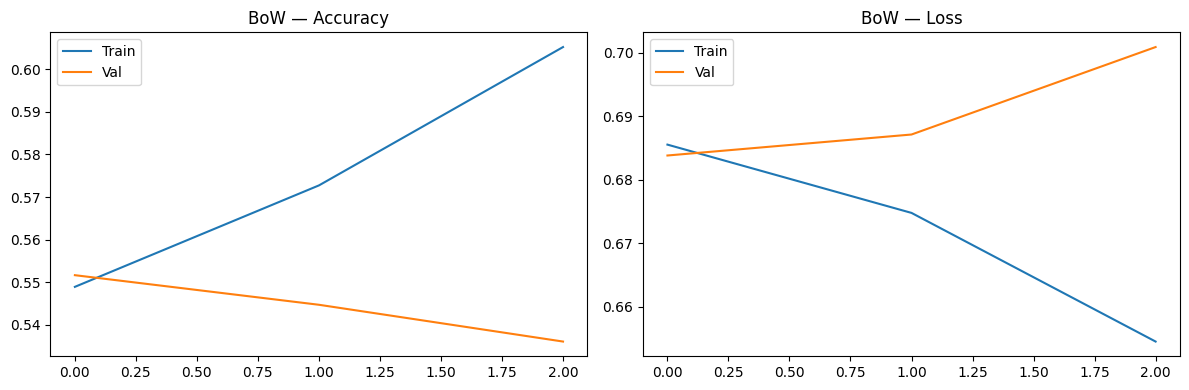

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 69s 11ms/step

Test Accuracy : 0.5559
F1 Score      : 0.5915
Precision     : 0.5476
Recall        : 0.6431


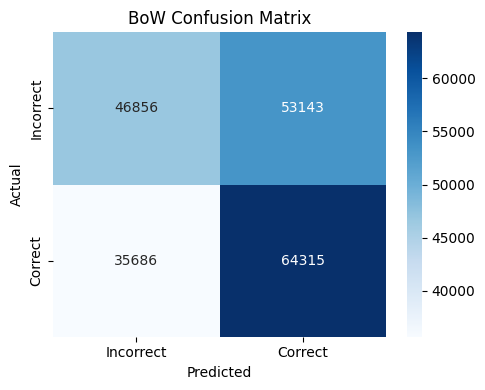


── Correct Predictions ──────────────────────────────────────────────────
  Sentence  : Hey don't be a hater, even I do dumbazz things.
  Actual    : 1  |  Predicted: 1
  ------------------------------------------------------------
  Sentence  : BERNARD HERRMANN (1911-1975): The Snows of Kilimanjaro, 5 Fingers.
  Actual    : 1  |  Predicted: 1
  ------------------------------------------------------------
  Sentence  : Offside, Chicago Red Stars Yuki Nagasato tried through ball, but to catch it Alyssa Mautz catch.
  Actual    : 0  |  Predicted: 0
  ------------------------------------------------------------

── Wrong Predictions ────────────────────────────────────────────────────
  Sentence  : Two degrees of savings Money Saver!
  Actual    : 1  |  Predicted: 0
  ------------------------------------------------------------
  Sentence  : I am so please to enjoy all your visit, Jessica .. I can never hold back on the gifts and always get my special presents here, as you say, they are 

In [5]:
import pandas as pd
# ── Build classification dataframe ────────────────────────────────────────────
incorrect_df     = pd.DataFrame({'text': df_BOW['incorrect'], 'label': 0})
correct_df       = pd.DataFrame({'text': df_BOW['correct'],   'label': 1})
classification_df = pd.concat([incorrect_df, correct_df], ignore_index=True)
classification_df = classification_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Classification shape:", classification_df.shape)

# ── Split ─────────────────────────────────────────────────────────────────────
X = classification_df['text']
y = classification_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Train:", len(X_train), "| Test:", len(X_test))

# ── Vectorize (fixed: 20k features) ──────────────────────────────────────────
vectorizer   = CountVectorizer(max_features=20_000)
X_train_bow  = vectorizer.fit_transform(X_train).astype('float32')
X_test_bow   = vectorizer.transform(X_test).astype('float32')

print("BoW train shape:", X_train_bow.shape)



# ── Model ─────────────────────────────────────────────────────────────────────
bow_model = Sequential([
    Dense(128, activation='relu', input_shape=(20_000,)),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(1,   activation='sigmoid')
])

bow_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bow_model.summary()



# ── Train ─────────────────────────────────────────────────────────────────────
checkpoint_cb = ModelCheckpoint(
    '/kaggle/working/checkpoints/bow_best.keras',
    monitor='val_accuracy', save_best_only=True, verbose=1
)
early_stop_cb = EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)

history = bow_model.fit(
    X_train_bow, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=512,
    callbacks=[checkpoint_cb, early_stop_cb]
)

# ── Training curves (required for report) ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('BoW — Accuracy');  ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('BoW — Loss');  ax2.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/saved_data/bow_curves.png', dpi=120)
plt.show()



# ── Evaluate ──────────────────────────────────────────────────────────────────
test_loss, test_acc = bow_model.evaluate(X_test_bow, y_test, verbose=0)
y_pred = (bow_model.predict(X_test_bow) > 0.5).astype(int)

print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"F1 Score      : {f1_score(y_test, y_pred):.4f}")
print(f"Precision     : {precision_score(y_test, y_pred):.4f}")
print(f"Recall        : {recall_score(y_test, y_pred):.4f}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Incorrect','Correct'],
            yticklabels=['Incorrect','Correct'])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("BoW Confusion Matrix")
plt.tight_layout()
plt.savefig('/kaggle/working/saved_data/bow_confusion.png', dpi=120)
plt.show()

# ── Examples ──────────────────────────────────────────────────────────────────
results_df    = pd.DataFrame({'text': X_test.values,
                               'actual': y_test.values,
                               'predicted': y_pred.flatten()})
correct_preds = results_df[results_df['actual'] == results_df['predicted']]
wrong_preds   = results_df[results_df['actual'] != results_df['predicted']]

print("\n── Correct Predictions ──────────────────────────────────────────────────")
for _, row in correct_preds.head(3).iterrows():
    print(f"  Sentence  : {row['text']}")
    print(f"  Actual    : {row['actual']}  |  Predicted: {row['predicted']}")
    print("  " + "-"*60)

print("\n── Wrong Predictions ────────────────────────────────────────────────────")
for _, row in wrong_preds.head(3).iterrows():
    print(f"  Sentence  : {row['text']}")
    print(f"  Actual    : {row['actual']}  |  Predicted: {row['predicted']}")
    print("  " + "-"*60)

# ── Save metrics for final comparison table ───────────────────────────────────
bow_metrics = {
    'model'    : 'BoW + DNN',
    'accuracy' : round(test_acc, 4),
    'f1'       : round(f1_score(y_test, y_pred), 4),
    'precision': round(precision_score(y_test, y_pred), 4),
    'recall'   : round(recall_score(y_test, y_pred), 4),
}
print("\nBoW Metrics:", bow_metrics)